# Abnormal Machine Sound Detection with the MIMII Dataset

## 1. Title and Notebook Purpose

This project delivers a reproducible deep learning pipeline for abnormal machine sound detection using the MIMII dataset. The main supported task is supervised binary classification of machine audio into `normal` and `abnormal`, with the baseline CNN serving as the official project deliverable.

This notebook is a concise walkthrough of the repository: it explains the project flow, previews the saved split strategy, reuses saved artifacts, and visualizes baseline results in a presentation-friendly format. It is designed as a guided demo layer for readers who want to understand the pipeline without digging through every implementation detail.

The official runnable workflows remain in the `.py` scripts under `scripts/`.


## 2. Project Overview

Abnormal machine sound detection asks whether an audio recording reflects normal operating behavior or a potential fault condition. In practice, this matters because missed anomalies can hide real equipment problems, while excessive false alarms can make a monitoring system difficult to trust.

This repository uses the **MIMII dataset**, which contains machine recordings from multiple machine families and operating conditions. In the main baseline workflow, the project is framed primarily as a **supervised binary classification** problem: given a processed audio example, predict `normal` or `abnormal`.

The broader project goal is not only to train a working model, but to build a **reproducible deep learning pipeline** with saved split manifests, deterministic preprocessing, reusable training and evaluation code, and persistent metrics and plots.


## 3. Official Baseline Workflow

The supported baseline workflow is intentionally simple and reproducible:

1. generate a saved split manifest
2. train the baseline CNN
3. evaluate the saved checkpoint
4. regenerate plots from saved artifacts

The notebook does **not** run these commands by default. It documents the workflow and then focuses on reading the saved artifacts that already capture a completed run.

```bash
python scripts/make_splits.py --seed 42

python scripts/train.py \
  --manifest-path data/splits/all_machines_split_seed42.csv \
  --epochs 10 \
  --batch-size 16 \
  --learning-rate 1e-3 \
  --run-name all_machines_baseline

python scripts/evaluate.py \
  --manifest-path data/splits/all_machines_split_seed42.csv \
  --checkpoint-path artifacts/checkpoints/all_machines_baseline/best.pt \
  --run-name all_machines_baseline

python scripts/plot_results.py \
  --history-path artifacts/metrics/all_machines_baseline/history.json \
  --metrics-path artifacts/metrics/all_machines_baseline/test_metrics.json \
  --run-name all_machines_baseline
```


## 4. Dataset and Task Formulation

The MIMII dataset used here spans four machine types represented in the saved all-machine manifest: **fan**, **pump**, **slider**, and **valve**. Each row in the split manifest points to one audio file plus metadata describing machine type, machine identity, signal-to-noise condition, label, and assigned split.

The learning task is binary classification with labels `normal` and `abnormal`. The dataset is class-imbalanced, with noticeably more normal examples than abnormal ones. In this setting, **recall matters** because a missed anomaly can be operationally costly even when overall accuracy remains high.


In [39]:
import json
import tempfile
import wave
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Image, Markdown, display

from src.data.transforms import BaselineLogMelTransform
from src.evaluation.plots import (
    load_json,
    plot_confusion_matrix,
    plot_loss_curves,
    plot_validation_accuracy,
)
from src.features.spectrogram import LogMelSpectrogramExtractor
from src.features.waveform import average_channels_to_mono
from src.models.cnn_baseline import BaselineCNN
from src.utils.io import resolve_path, to_portable_path

from IPython.display import display

import tempfile
from pathlib import Path
from IPython.display import Image, display

def show_figure_via_png(fig, filename_prefix="figure"):
    temp_dir = Path(tempfile.gettempdir())
    output_path = temp_dir / f"{filename_prefix}.png"
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=str(output_path)))

plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 4.5)


def find_manifest_path(preferred='data/splits/all_machines_split_seed42.csv'):
    preferred_path = resolve_path(preferred)
    if preferred_path.exists():
        return preferred_path

    split_dir = resolve_path('data/splits')
    if not split_dir.exists():
        return None

    csv_candidates = sorted(
        path for path in split_dir.glob('*.csv') if path.name != 'master_index.csv'
    )
    return csv_candidates[0] if csv_candidates else None


def find_run_dir(preferred_run=None, keyword=None):
    metrics_root = resolve_path('artifacts/metrics')
    if preferred_run:
        preferred_dir = metrics_root / preferred_run
        if preferred_dir.exists():
            return preferred_dir

    if not metrics_root.exists():
        return None

    candidates = [path for path in sorted(metrics_root.iterdir()) if path.is_dir()]
    if keyword is not None:
        filtered = [path for path in candidates if keyword.lower() in path.name.lower()]
        if filtered:
            candidates = filtered

    sensible = [
        path
        for path in candidates
        if (path / 'history.json').exists() or (path / 'test_metrics.json').exists()
    ]
    return sensible[0] if sensible else None


def safe_load_json(path):
    if path is None:
        return None
    try:
        return load_json(path)
    except Exception as exc:
        print(f'Could not load {path}: {exc}')
        return None


def display_note(message):
    display(Markdown(f'> {message}'))


def metric_table(metrics, keys):
    if metrics is None:
        return pd.DataFrame()

    rows = []
    for key in keys:
        if key in metrics:
            value = metrics[key]
            if isinstance(value, float):
                value = round(value, 4)
            rows.append({'metric': key, 'value': value})
    return pd.DataFrame(rows)


def load_wave_audio(path):
    audio_path = resolve_path(path)
    with wave.open(str(audio_path), 'rb') as wav_file:
        n_channels = wav_file.getnchannels()
        sample_rate = wav_file.getframerate()
        sample_width = wav_file.getsampwidth()
        n_frames = wav_file.getnframes()
        audio_bytes = wav_file.readframes(n_frames)

    dtype_map = {1: np.uint8, 2: np.int16, 4: np.int32}
    if sample_width not in dtype_map:
        raise ValueError(f'Unsupported WAV sample width: {sample_width} bytes')

    waveform = np.frombuffer(audio_bytes, dtype=dtype_map[sample_width]).reshape(-1, n_channels)
    if sample_width == 1:
        waveform = (waveform.astype(np.float32) - 128.0) / 128.0
    else:
        waveform = waveform.astype(np.float32) / float(2 ** (8 * sample_width - 1))

    return torch.from_numpy(waveform.T.copy()), sample_rate


def find_audio_example(manifest_df=None):
    if manifest_df is not None and 'filepath' in manifest_df.columns:
        for relative_path in manifest_df['filepath']:
            candidate = resolve_path(relative_path)
            if candidate.exists():
                return candidate

    raw_dir = resolve_path('data/raw')
    if raw_dir.exists():
        wav_candidates = sorted(raw_dir.rglob('*.wav'))
        if wav_candidates:
            return wav_candidates[0]
    return None


def display_generated_plot(plot_path):
    if Path(plot_path).exists():
        display(Image(filename=str(plot_path)))
    else:
        display_note(f'Plot file was not created: {plot_path}')


manifest_path = find_manifest_path()
manifest_df = pd.read_csv(manifest_path) if manifest_path else None

baseline_run_dir = find_run_dir(preferred_run='all_machines_baseline', keyword='baseline')
baseline_run_name = baseline_run_dir.name if baseline_run_dir else None
baseline_history_path = baseline_run_dir / 'history.json' if baseline_run_dir else None
baseline_metrics_path = baseline_run_dir / 'test_metrics.json' if baseline_run_dir else None
baseline_run_config_path = baseline_run_dir / 'run_config.json' if baseline_run_dir else None
baseline_curve_dir = resolve_path(f'artifacts/curves/{baseline_run_name}') if baseline_run_name else None

baseline_history = safe_load_json(baseline_history_path)
baseline_test_metrics = safe_load_json(baseline_metrics_path)
baseline_run_config = safe_load_json(baseline_run_config_path)

autoencoder_run_dir = find_run_dir(preferred_run='all_machines_autoencoder_v1', keyword='autoencoder')
autoencoder_metrics_path = autoencoder_run_dir / 'test_metrics.json' if autoencoder_run_dir else None
autoencoder_test_metrics = safe_load_json(autoencoder_metrics_path)


In [40]:
if manifest_df is None:
    display_note('No saved split manifest was found under `data/splits/`.')
else:
    print(f'Using manifest: {to_portable_path(manifest_path)}')
    display(manifest_df.head())

    split_counts = (
        manifest_df['split']
        .value_counts()
        .rename_axis('split')
        .reset_index(name='num_rows')
    )
    class_counts = (
        manifest_df.groupby(['split', 'label'])
        .size()
        .rename('num_rows')
        .reset_index()
    )

    display(split_counts)
    display(class_counts)


Using manifest: data/splits/all_machines_split_seed42.csv


,filepath,machine_type,snr_db,machine_id,label,group_id,split
0,data/raw/0_dB_fan/id_00/abnormal/00000000.wav,fan,0_dB,id_00,abnormal,fan__id_00__0_dB,test
1,data/raw/0_dB_fan/id_00/abnormal/00000001.wav,fan,0_dB,id_00,abnormal,fan__id_00__0_dB,test
2,data/raw/0_dB_fan/id_00/abnormal/00000002.wav,fan,0_dB,id_00,abnormal,fan__id_00__0_dB,test
3,data/raw/0_dB_fan/id_00/abnormal/00000003.wav,fan,0_dB,id_00,abnormal,fan__id_00__0_dB,test
4,data/raw/0_dB_fan/id_00/abnormal/00000004.wav,fan,0_dB,id_00,abnormal,fan__id_00__0_dB,test


,split,num_rows
0,train,36038
1,test,9116
2,val,8903


,split,label,num_rows
0,test,abnormal,1771
1,test,normal,7345
2,train,abnormal,6600
3,train,normal,29438
4,val,abnormal,1529
5,val,normal,7374


## 5. Split Strategy and Reproducibility

A naive random split at the file level can leak information because recordings from the same machine identity and operating condition may be extremely similar. If near-duplicate conditions are spread across train, validation, and test, the reported metrics can look stronger than the true generalization behavior.

In this repository, grouping follows **machine identity and recording-condition logic**. The saved split manifest is treated as the source of truth, which means downstream training, evaluation, and plotting all refer back to a fixed CSV instead of rebuilding a split on the fly.

Reproducibility depends on keeping together the same split manifest, checkpoint files, training history JSON, and final metrics JSON. That combination is what allows the reported baseline run to be reproduced cleanly without reimplementing the workflow in the notebook.


In [41]:
if manifest_df is None:
    display_note('Split summary is unavailable because no manifest could be loaded.')
else:
    split_summary = (
        manifest_df.groupby('split')
        .agg(
            rows=('filepath', 'size'),
            unique_groups=('group_id', 'nunique'),
            machine_types=('machine_type', 'nunique'),
            abnormal_fraction=('label', lambda s: (s == 'abnormal').mean()),
        )
        .reset_index()
    )
    split_summary['abnormal_fraction'] = split_summary['abnormal_fraction'].round(4)
    display(split_summary)


,split,rows,unique_groups,machine_types,abnormal_fraction
0,test,9116,8,4,0.1943
1,train,36038,32,4,0.1831
2,val,8903,8,4,0.1717


## 6. Preprocessing: From Waveform to Log-Mel Spectrogram

The raw MIMII recordings in this repository are **8-channel audio**. For the baseline workflow, the channels are averaged to mono in a deterministic way, and the mono waveform is converted into a **log-mel spectrogram**. That log-mel image is the actual model input.

This representation is a practical baseline because it compresses the time-domain signal into a frequency-aware view that is well suited to convolutional models. It also aligns with the repository's deterministic preprocessing setup: fixed sample rate, fixed STFT parameters, fixed mel-bin count, and no notebook-only feature engineering.


Normal example:
  path: data/raw/0_dB_fan/id_00/normal/00000000.wav
  machine_type: fan
  machine_id: id_00
  split: test
  label: normal
  log-mel shape: (64, 313)

Abnormal example:
  path: data/raw/0_dB_fan/id_00/abnormal/00000000.wav
  machine_type: fan
  machine_id: id_00
  split: test
  label: abnormal
  log-mel shape: (64, 313)


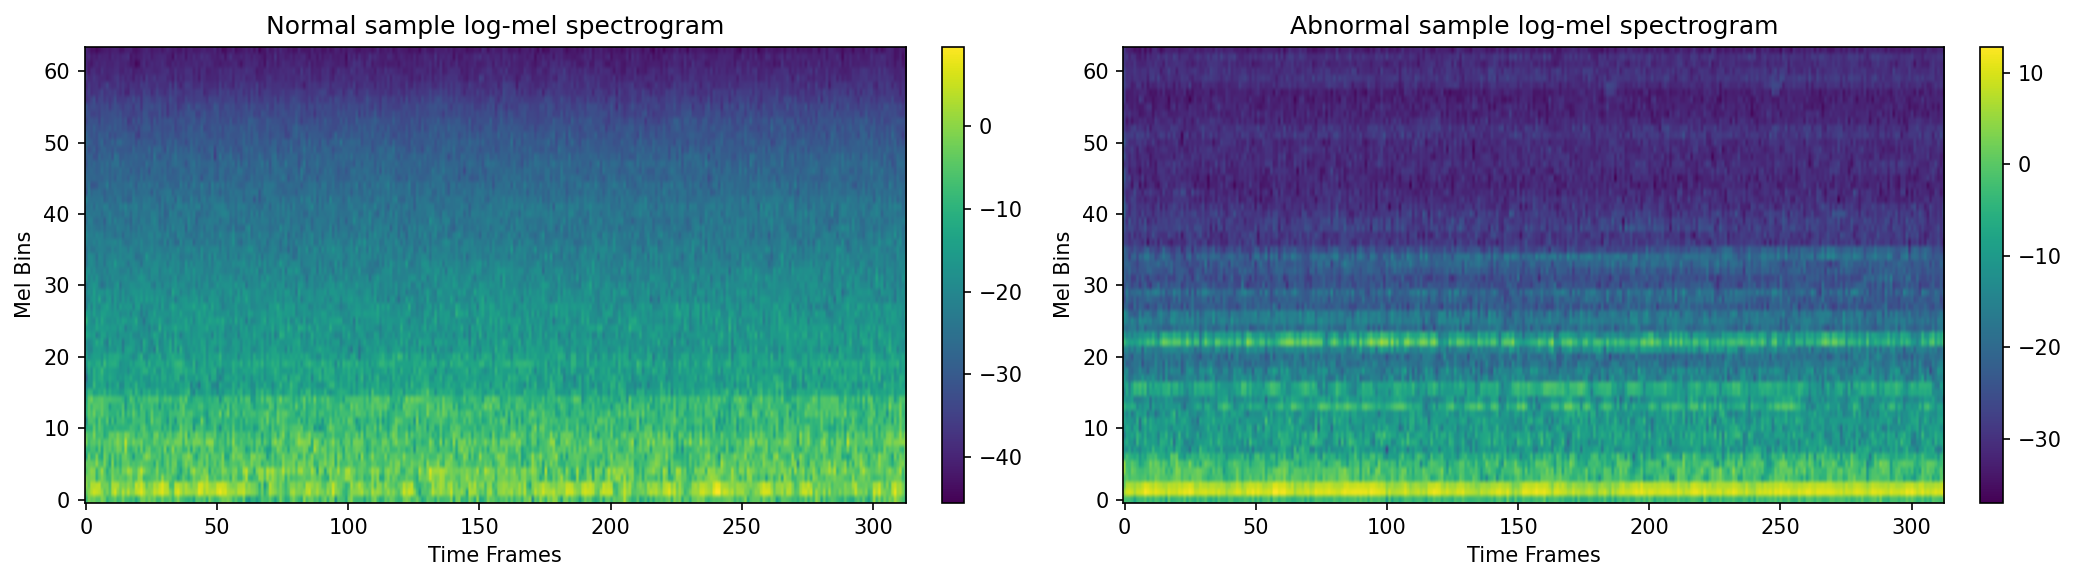

In [42]:
def find_example_by_label(manifest_df, target_label):
    if "label" not in manifest_df.columns:
        return None

    target_str = str(target_label).strip().lower()

    candidates = manifest_df[
        manifest_df["label"].astype(str).str.strip().str.lower() == target_str
    ]

    if candidates.empty:
        return None

    for _, row in candidates.iterrows():
        candidate_path = resolve_audio_path(row)
        if candidate_path is not None:
            return row

    return None

def resolve_audio_path(row):
    candidate_columns = [
        "filepath",
        "file_path",
        "path",
        "audio_path",
        "wav_path",
        "filename",
    ]

    for col in candidate_columns:
        if col in row.index and pd.notna(row[col]):
            raw_value = str(row[col]).strip()
            if raw_value:
                path = resolve_path(raw_value)
                if path.exists():
                    return path

    return None


preprocessing_params = (
    baseline_run_config.get("preprocessing_parameters", {}) if baseline_run_config else {}
)

normal_row = find_example_by_label(manifest_df, "normal")
abnormal_row = find_example_by_label(manifest_df, "abnormal")

if normal_row is None or abnormal_row is None:
    display_note("Could not find both a usable normal and abnormal sample from the manifest.")
else:
    try:
        normal_path = resolve_audio_path(normal_row)
        abnormal_path = resolve_audio_path(abnormal_row)

        normal_waveform, normal_sr = load_wave_audio(normal_path)
        abnormal_waveform, abnormal_sr = load_wave_audio(abnormal_path)

        normal_mono = average_channels_to_mono(normal_waveform)
        abnormal_mono = average_channels_to_mono(abnormal_waveform)

        extractor = LogMelSpectrogramExtractor(**preprocessing_params)

        normal_log_mel = extractor(normal_mono, sample_rate=normal_sr)
        abnormal_log_mel = extractor(abnormal_mono, sample_rate=abnormal_sr)

        print("Normal example:")
        print(f"  path: {to_portable_path(normal_path)}")
        print(f"  machine_type: {normal_row['machine_type']}")
        print(f"  machine_id: {normal_row['machine_id']}")
        print(f"  split: {normal_row['split']}")
        print(f"  label: {normal_row['label']}")
        print(f"  log-mel shape: {tuple(normal_log_mel.shape)}")

        print("\nAbnormal example:")
        print(f"  path: {to_portable_path(abnormal_path)}")
        print(f"  machine_type: {abnormal_row['machine_type']}")
        print(f"  machine_id: {abnormal_row['machine_id']}")
        print(f"  split: {abnormal_row['split']}")
        print(f"  label: {abnormal_row['label']}")
        print(f"  log-mel shape: {tuple(abnormal_log_mel.shape)}")

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        im0 = axes[0].imshow(
            normal_log_mel.detach().cpu().numpy(),
            aspect="auto",
            origin="lower"
        )
        axes[0].set_title("Normal sample log-mel spectrogram")
        axes[0].set_xlabel("Time Frames")
        axes[0].set_ylabel("Mel Bins")
        fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

        im1 = axes[1].imshow(
            abnormal_log_mel.detach().cpu().numpy(),
            aspect="auto",
            origin="lower"
        )
        axes[1].set_title("Abnormal sample log-mel spectrogram")
        axes[1].set_xlabel("Time Frames")
        axes[1].set_ylabel("Mel Bins")
        fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

        fig.tight_layout()
        show_figure_via_png(fig, "normal_vs_abnormal_logmel")

    except Exception as exc:
        display_note(
            "Normal-vs-abnormal spectrogram comparison could not be rendered "
            f"({type(exc).__name__}: {exc})."
        )

## 7. Baseline CNN Model

A CNN is a reasonable baseline here because the input is a 2D time-frequency representation. Local convolutional filters can learn useful patterns such as energy bands, transient events, and broader texture differences between normal and abnormal machine behavior.

The repository baseline expects inputs with shape **`[batch, 1, 64, time]`** and produces a **single logit** per sample for binary classification.


In [43]:
model = BaselineCNN()
parameter_count = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
print(f'Trainable parameters: {parameter_count:,}')
model


Trainable parameters: 31,969


BaselineCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (batch_norm1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (batch_norm2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (batch_norm3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout2d(p=0.1, inplace=False)
  (dropout2): Dropout2d(p=0.15, inplace=False)
  (dropout3): Dropout2d(p=0.2, inplace=False)
  (dropout_fc): Dropout(p=0.3, inplace=False)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc1): Linear(in_features=64, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)

## 8. Training Workflow Summary

The baseline training workflow uses mini-batch optimization with validation at the end of every epoch. Two checkpoint concepts are maintained: a **best checkpoint** for the strongest validation loss seen so far, and a **last checkpoint** for resume and recovery behavior.

The saved run artifacts also include a `history.json` file with per-epoch metrics and a `run_config.json` file that records the configuration used for that training run. The notebook reads those files directly rather than retraining the model.


In [44]:
if baseline_run_config is None:
    display_note('No saved baseline run configuration was found under `artifacts/metrics/`.')
else:
    print(f'Using run config: {to_portable_path(baseline_run_config_path)}')
    run_config_summary = pd.DataFrame(
        [
            ('run_name', baseline_run_config.get('run_name')),
            ('manifest_path', baseline_run_config.get('manifest_path')),
            ('model_name', baseline_run_config.get('model_name')),
            ('loss_name', baseline_run_config.get('loss_name')),
            ('optimizer_name', baseline_run_config.get('optimizer_name')),
            ('batch_size', baseline_run_config.get('batch_size')),
            ('learning_rate', baseline_run_config.get('learning_rate')),
            ('epochs_requested', baseline_run_config.get('epochs_requested')),
            ('preprocessing_name', baseline_run_config.get('preprocessing_name')),
        ],
        columns=['setting', 'value'],
    )
    display(run_config_summary)


Using run config: artifacts/metrics/all_machines_baseline/run_config.json


,setting,value
0,run_name,all_machines_baseline
1,manifest_path,data/splits/all_machines_split_seed42.csv
2,model_name,BaselineCNN
3,loss_name,BCEWithLogitsLoss
4,optimizer_name,Adam
5,batch_size,16
6,learning_rate,0.001
7,epochs_requested,10
8,preprocessing_name,BaselineLogMelTransform


## 9. Reproducing Saved Results

This section focuses on the saved-artifact workflow. Instead of rerunning training, we load the stored history and test metrics for the preferred baseline run and display them in a compact, readable format.


In [45]:
if baseline_history is None:
    display_note('No saved `history.json` file was found for the baseline run.')
else:
    print(f'History file: {to_portable_path(baseline_history_path)}')
    display(pd.DataFrame(baseline_history['epochs']).tail(3))

if baseline_test_metrics is None:
    display_note('No saved `test_metrics.json` file was found for the baseline run.')
else:
    print(f'Test metrics file: {to_portable_path(baseline_metrics_path)}')
    display(
        metric_table(
            baseline_test_metrics,
            ['loss', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'num_samples'],
        )
    )

    if 'confusion_matrix' in baseline_test_metrics:
        cm = pd.DataFrame(
            baseline_test_metrics['confusion_matrix'],
            index=['true_normal', 'true_abnormal'],
            columns=['pred_normal', 'pred_abnormal'],
        )
        display(cm)


History file: artifacts/metrics/all_machines_baseline/history.json


,epoch,train_loss,val_loss,val_accuracy,epoch_time_seconds
7,8,0.175008,0.120581,0.953836,376.190859
8,9,0.165323,0.089506,0.964506,370.784767
9,10,0.163151,0.114710,0.959564,371.161329


Test metrics file: artifacts/metrics/all_machines_baseline/test_metrics.json


,metric,value
0,loss,0.0636
1,accuracy,0.9763
2,precision,0.9887
3,recall,0.8882
4,f1,0.9358
5,roc_auc,0.9952
6,num_samples,9116.0000


,pred_normal,pred_abnormal
true_normal,7327,18
true_abnormal,198,1573


## 10. Baseline Performance Visualizations

The figures below are generated from the saved baseline artifacts using the repository's existing plotting helpers whenever possible.


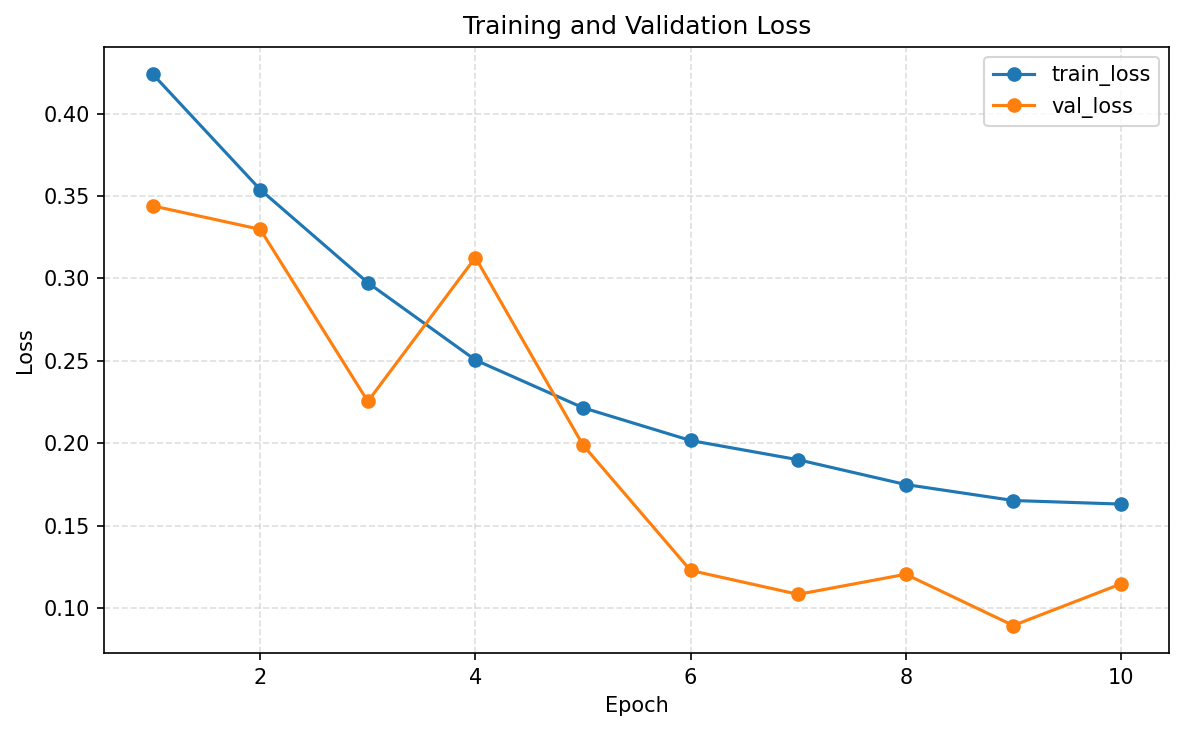

In [46]:
loss_plot_path = Path(tempfile.gettempdir()) / f'{baseline_run_name or "baseline"}_loss_curve.png'
fallback_loss_plot = baseline_curve_dir / 'loss_curve.png' if baseline_curve_dir else None

if baseline_history is not None:
    try:
        rendered_path = plot_loss_curves(baseline_history, loss_plot_path)
        display_generated_plot(rendered_path)
    except Exception as exc:
        if fallback_loss_plot and fallback_loss_plot.exists():
            display_generated_plot(fallback_loss_plot)
        else:
            display_note(f'Could not render the loss curve: {exc}')
elif fallback_loss_plot and fallback_loss_plot.exists():
    display_generated_plot(fallback_loss_plot)
else:
    display_note('No loss-curve artifact is available for display.')


The training and validation losses decrease in a stable way, and the saved best epoch reflects a point where validation performance remains well controlled rather than drifting sharply upward. That is a good sign for a baseline intended to be reproducible and dependable.


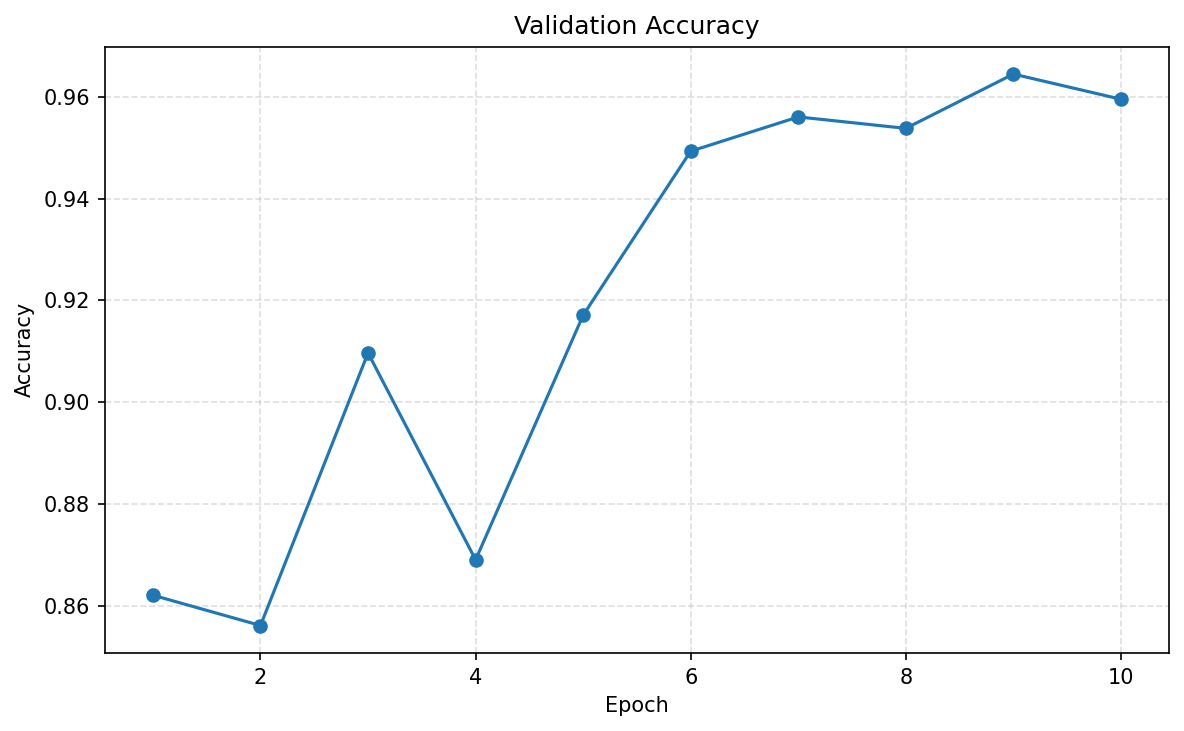

In [47]:
val_acc_plot_path = Path(tempfile.gettempdir()) / f'{baseline_run_name or "baseline"}_val_accuracy_curve.png'
fallback_val_plot = baseline_curve_dir / 'val_accuracy_curve.png' if baseline_curve_dir else None

if baseline_history is not None:
    try:
        rendered_path = plot_validation_accuracy(baseline_history, val_acc_plot_path)
        display_generated_plot(rendered_path)
    except Exception as exc:
        if fallback_val_plot and fallback_val_plot.exists():
            display_generated_plot(fallback_val_plot)
        else:
            display_note(f'Could not render the validation-accuracy curve: {exc}')
elif fallback_val_plot and fallback_val_plot.exists():
    display_generated_plot(fallback_val_plot)
else:
    display_note('No validation-accuracy artifact is available for display.')


Validation accuracy improves quickly and settles in the mid-to-high 90% range for the saved baseline run. This supports the view that the baseline CNN is learning a strong separation on the held-out validation split without needing a more complex architecture to establish a solid first benchmark.


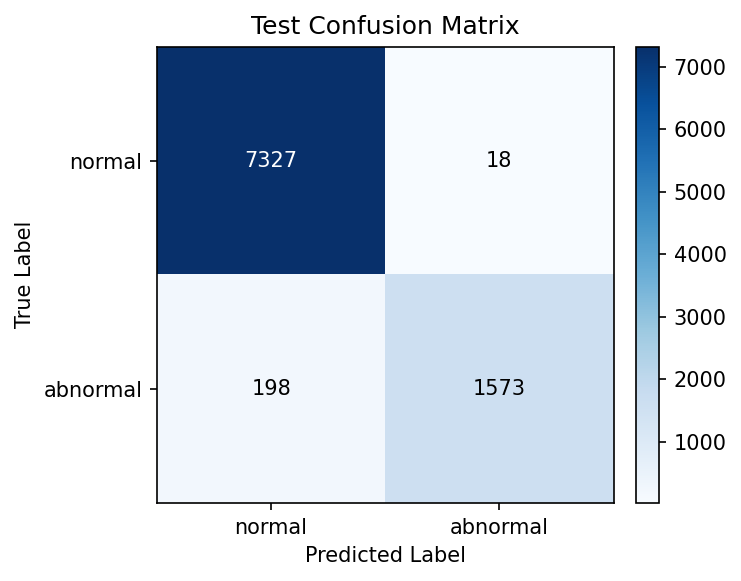

In [48]:
cm_plot_path = Path(tempfile.gettempdir()) / f'{baseline_run_name or "baseline"}_confusion_matrix.png'
fallback_cm_plot = baseline_curve_dir / 'confusion_matrix.png' if baseline_curve_dir else None

if baseline_test_metrics is not None and 'confusion_matrix' in baseline_test_metrics:
    try:
        rendered_path = plot_confusion_matrix(baseline_test_metrics['confusion_matrix'], cm_plot_path)
        display_generated_plot(rendered_path)
    except Exception as exc:
        if fallback_cm_plot and fallback_cm_plot.exists():
            display_generated_plot(fallback_cm_plot)
        else:
            display_note(f'Could not render the confusion matrix: {exc}')
elif fallback_cm_plot and fallback_cm_plot.exists():
    display_generated_plot(fallback_cm_plot)
else:
    display_note('No confusion-matrix artifact is available for display.')


The confusion matrix shows that most examples are classified correctly, with especially few false positives. The remaining errors are more concentrated in missed anomalies than in false alarms, which matches the precision-recall pattern seen in the saved metrics.


## 11. Interpretation of Results

The saved baseline results indicate a **strong CNN benchmark** for this repository. Precision is very high, which means abnormal predictions are usually correct. Recall is slightly lower than precision, which suggests the model is somewhat conservative in declaring anomalies.

That trade-off is typical in anomaly detection: reducing false alarms can increase the chance of missed anomalies, while pushing recall higher can trigger more false positives. For the current saved baseline, the model already provides a strong reproducible starting point with high accuracy and very strong ROC-AUC, while still leaving room for future recall-oriented improvements.


## 12. Model Improvements and Team Extensions

After establishing a stable baseline CNN, additional experiments were conducted to improve anomaly detection performance. These extensions focused on improving training configuration, handling class imbalance, and refining model behavior without immediately introducing complex architectural changes.

### Hyperparameter Tuning

The first step was to optimize key training parameters, specifically the learning rate and batch size.

A two-stage strategy was used:
- tuning on a smaller single-machine (fan) subset
- extending the best configuration to the full all-machine dataset

For the all-machine setting, the best configuration was:
- learning rate: 0.001
- batch size: 16

This resulted in improved performance compared to the untuned baseline:
- Accuracy: 0.9854
- Precision: 0.9669
- Recall: 0.9577
- F1 score: 0.9623
- ROC-AUC: 0.9968

These results show that even without changing the architecture, careful tuning can significantly improve recall while maintaining high precision.

### Class-Weighted Loss

To address class imbalance and improve anomaly detection sensitivity, a class-weighted loss was introduced.

The baseline model showed higher precision than recall, indicating that it was conservative in predicting anomalies. To correct this, a positive class weight (`pos_weight`) was added to penalize missed abnormal samples more strongly.

The best balanced configuration used:
- pos_weight: 1.5

Resulting performance:
- Accuracy: 0.9888
- Precision: 0.9717
- Recall: 0.9706
- F1 score: 0.9712
- ROC-AUC: 0.9983

This significantly improved recall while maintaining strong precision, making the model more effective for anomaly detection tasks. 

### Threshold Tuning

The default classification threshold of 0.5 was further optimized to better balance precision and recall.

Lower thresholds increase recall but also increase false positives. A threshold sweep was conducted to find a practical operating point.

The selected threshold was:
- threshold: 0.42

Resulting performance:
- Accuracy: 0.9867
- Precision: 0.9578
- Recall: 0.9746
- F1 score: 0.9661

This provided a strong balance between detecting anomalies and limiting false alarms.

Threshold tuning was later repeated for the deeper CNN, which became the strongest model overall. The same selected threshold of `0.42` remained a good practical compromise, and this threshold-tuned deeper CNN became the final reported model.

### Architecture Exploration

Two simple architectural variants were explored to test whether increasing model capacity could improve performance:

**1. Wider CNN**
- Increased number of filters in each convolutional layer
- Did not improve performance significantly
- Slight drop in precision compared to the weighted baseline

**2. Deeper CNN**
- Added an additional convolutional block
- Improved performance across all metrics

Key results (before final threshold tuning):
- Accuracy: 0.9895
- Precision: 0.9661
- Recall: 0.9802
- F1 score: 0.9731
- ROC-AUC: 0.9986

This suggests that increasing depth is more effective than increasing width for capturing complex time-frequency patterns in machine sounds.

### Summary of Improvements

Overall, the extensions demonstrate that:

- Hyperparameter tuning improves general performance
- Class-weighted loss significantly improves anomaly sensitivity (recall)
- Threshold tuning allows control over precision–recall trade-offs
- Increasing model depth provides the most meaningful architectural improvement

These experiments collectively move the model from a strong baseline to a more robust and anomaly-sensitive system.

## 13. Final Selected Model

The final model selected for this project is the **deeper CNN** combined with a **tuned decision threshold of 0.42**.

Earlier baseline evaluation used the default threshold of `0.5`, but later experiments showed that threshold tuning improved the balance between anomaly sensitivity and false alarm rate. For the deeper CNN, a validation-based threshold selection process identified `0.42` as the final operating point.

This final model therefore consists of:

- architecture: deeper CNN
- checkpoint: `artifacts/checkpoints/all_machines_deeper_cnn/best.pt`
- selected threshold: `0.42`
- threshold tuning artifacts: `artifacts/threshold_tuning/all_machines_deeper_cnn/deeper_final_threshold_0p42/`

This notebook does not retrain the model. Instead, it loads the saved checkpoint, saved training history, and the saved threshold-tuning artifacts as the reproducible source of truth for the final selected system.

In [49]:
final_run_name = "all_machines_deeper_cnn"
final_threshold_tag = "deeper_final_threshold_0p42"

# Core model artifacts
final_checkpoint_path = resolve_path(f"artifacts/checkpoints/{final_run_name}/best.pt")
final_metrics_dir = resolve_path(f"artifacts/metrics/{final_run_name}")
final_curves_dir = resolve_path(f"artifacts/curves/{final_run_name}")

final_history_path = final_metrics_dir / "history.json"
final_run_config_path = final_metrics_dir / "run_config.json"

# Threshold-tuning artifacts for the final selected operating point
final_threshold_dir = resolve_path(
    f"artifacts/threshold_tuning/{final_run_name}/{final_threshold_tag}"
)
final_selected_threshold_path = final_threshold_dir / "val_selected_threshold.json"
final_selected_test_metrics_path = final_threshold_dir / "selected_threshold_test_metrics.json"
final_threshold_summary_json_path = final_threshold_dir / "val_threshold_summary.json"
final_threshold_summary_csv_path = final_threshold_dir / "val_threshold_summary.csv"

print(f"Final checkpoint: {to_portable_path(final_checkpoint_path)}")
print(f"Checkpoint exists: {final_checkpoint_path.exists()}")
print(f"History exists: {final_history_path.exists()}")
print(f"Run config exists: {final_run_config_path.exists()}")
print(f"Threshold selection file exists: {final_selected_threshold_path.exists()}")
print(f"Threshold-tuned test metrics exist: {final_selected_test_metrics_path.exists()}")

final_history = safe_load_json(final_history_path) if final_history_path.exists() else None
final_run_config = safe_load_json(final_run_config_path) if final_run_config_path.exists() else None

final_threshold_selection = (
    safe_load_json(final_selected_threshold_path)
    if final_selected_threshold_path.exists()
    else None
)
final_test_metrics = (
    safe_load_json(final_selected_test_metrics_path)
    if final_selected_test_metrics_path.exists()
    else None
)
final_threshold_summary = None
if final_threshold_summary_json_path.exists():
    try:
        with open(final_threshold_summary_json_path, "r", encoding="utf-8") as f:
            final_threshold_summary = json.load(f)
    except Exception as exc:
        print(f"Could not load {final_threshold_summary_json_path}: {exc}")
        final_threshold_summary = None

Final checkpoint: artifacts/checkpoints/all_machines_deeper_cnn/best.pt
Checkpoint exists: True
History exists: True
Run config exists: True
Threshold selection file exists: True
Threshold-tuned test metrics exist: True


### Final Model Results

The deeper CNN became the strongest architecture among the controlled experiments, but the final reported operating point also depends on threshold tuning.

Using the validation split, the selected threshold was:

- threshold: `0.42`

The saved threshold-selection record also shows that this final thresholding step was tracked explicitly under the run tag `deeper_final_threshold_0p42`.

The metrics shown below correspond to the **threshold-tuned final model**, not the default `0.5` prediction threshold.

In [50]:
if final_test_metrics is not None:
    display(
        metric_table(
            final_test_metrics,
            ["loss", "accuracy", "precision", "recall", "f1", "roc_auc", "num_samples"],
        )
    )

    if "confusion_matrix" in final_test_metrics:
        final_cm = pd.DataFrame(
            final_test_metrics["confusion_matrix"],
            index=["true_normal", "true_abnormal"],
            columns=["pred_normal", "pred_abnormal"],
        )
        display(final_cm)
else:
    display_note(
        "Saved final-model metrics were not found, so only the checkpoint path is shown here."
    )

,metric,value
0,loss,0.0362
1,accuracy,0.9877
2,precision,0.9545
3,recall,0.9836
4,f1,0.9689
5,roc_auc,0.9986


,pred_normal,pred_abnormal
true_normal,7262,83
true_abnormal,29,1742


### Final Model Visualizations

The figures below summarize the saved training dynamics and final test-set behavior of the selected deeper CNN model.

In [51]:
if final_threshold_selection is not None:
    threshold_summary_table = pd.DataFrame(
        [
            ("run_name", final_threshold_selection.get("run_name")),
            ("run_tag", final_threshold_selection.get("run_tag")),
            ("tuned_split", final_threshold_selection.get("tuned_split")),
            ("selection_metric", final_threshold_selection.get("selection_metric")),
            ("selected_threshold", final_threshold_selection.get("selected_threshold")),
            ("checkpoint_path", final_threshold_selection.get("checkpoint_path")),
        ],
        columns=["setting", "value"],
    )
    display(threshold_summary_table)

    if "selected_metrics" in final_threshold_selection:
        print("Validation metrics at selected threshold:")
        display(
            metric_table(
                final_threshold_selection["selected_metrics"],
                ["loss", "accuracy", "precision", "recall", "f1", "roc_auc"],
            )
        )
else:
    display_note("No saved validation threshold-selection record was found for the final model.")

if final_test_metrics is not None:
    print("Test metrics at selected threshold:")
    display(
        metric_table(
            final_test_metrics,
            ["threshold", "loss", "accuracy", "precision", "recall", "f1", "roc_auc"],
        )
    )

    if "confusion_matrix" in final_test_metrics:
        final_cm = pd.DataFrame(
            final_test_metrics["confusion_matrix"],
            index=["true_normal", "true_abnormal"],
            columns=["pred_normal", "pred_abnormal"],
        )
        display(final_cm)
else:
    display_note(
        "Saved threshold-tuned test metrics were not found, so only the checkpoint path is shown here."
    )

if final_threshold_summary is not None:
    print("Validation threshold summary:")
    display(pd.DataFrame(final_threshold_summary))

,setting,value
0,run_name,all_machines_deeper_cnn
1,run_tag,deeper_final_threshold_0p42
2,tuned_split,val
3,selection_metric,recall
4,selected_threshold,0.42
5,checkpoint_path,artifacts\checkpoints\all_machines_deeper_cnn\...


Validation metrics at selected threshold:


,metric,value
0,loss,0.0183
1,accuracy,0.9933
2,precision,0.9736
3,recall,0.9876
4,f1,0.9805
5,roc_auc,0.9995


Test metrics at selected threshold:


,metric,value
0,threshold,0.4200
1,loss,0.0362
2,accuracy,0.9877
3,precision,0.9545
4,recall,0.9836
5,f1,0.9689
6,roc_auc,0.9986


,pred_normal,pred_abnormal
true_normal,7262,83
true_abnormal,29,1742


Validation threshold summary:


,split,threshold,loss,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp
0,val,0.42,0.018311,0.993261,0.973565,0.987574,0.980519,0.999481,7333,41,19,1510


### Final Model Visualizations

The figures below summarize the saved training dynamics of the deeper CNN and the final test-set behavior at the selected threshold of `0.42`.

The loss and validation-accuracy curves come from the saved training history for `all_machines_deeper_cnn`, while the confusion matrix comes from the threshold-tuned final test metrics stored under the threshold-tuning artifacts.

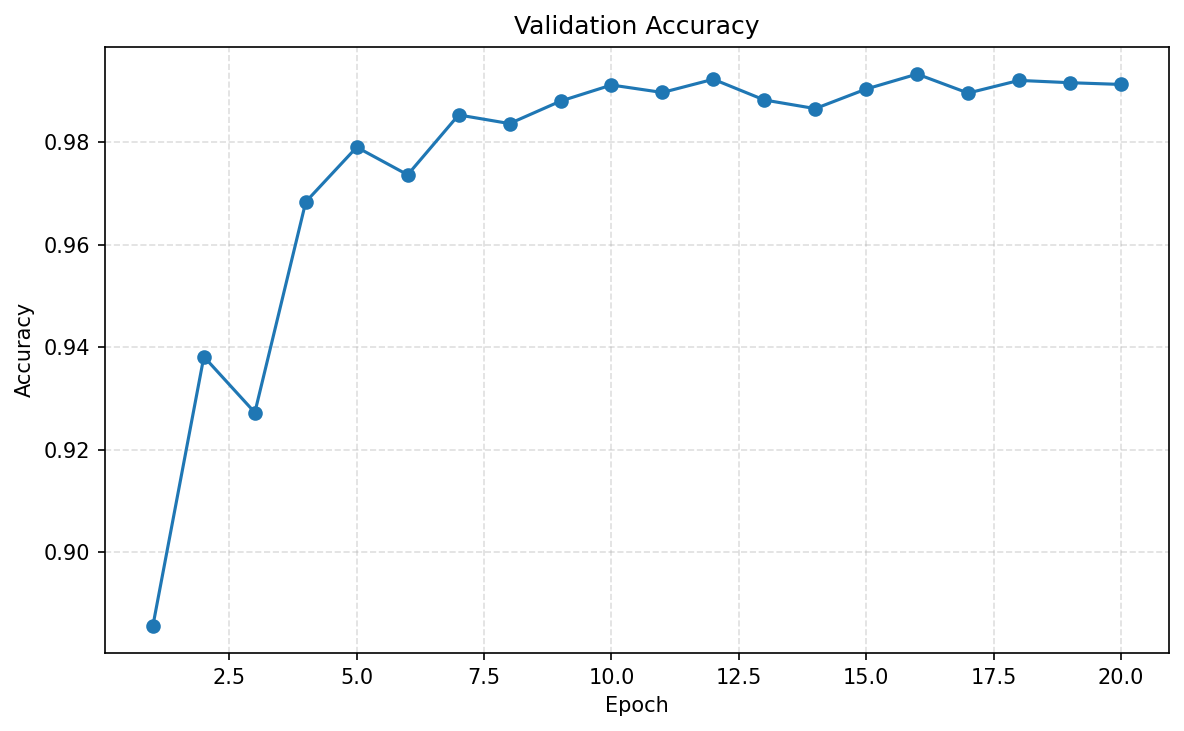

In [52]:
final_val_acc_plot_path = Path(tempfile.gettempdir()) / f"{final_run_name}_val_accuracy_curve.png"
final_fallback_val_plot = final_curves_dir / "val_accuracy_curve.png" if final_curves_dir.exists() else None

if final_history is not None:
    try:
        rendered_path = plot_validation_accuracy(final_history, final_val_acc_plot_path)
        display_generated_plot(rendered_path)
    except Exception as exc:
        if final_fallback_val_plot and final_fallback_val_plot.exists():
            display_generated_plot(final_fallback_val_plot)
        else:
            display_note(f"Could not render the final-model validation-accuracy curve: {exc}")
elif final_fallback_val_plot and final_fallback_val_plot.exists():
    display_generated_plot(final_fallback_val_plot)
else:
    display_note("No saved validation-accuracy artifact is available for the final model.")

Validation accuracy shows how the deeper CNN improved across epochs and helps verify that the stronger model remained well-behaved during training.

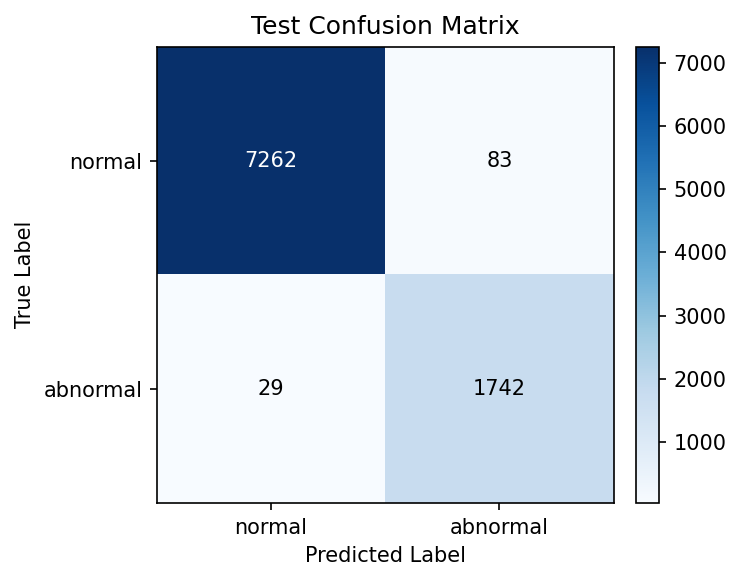

Using threshold-tuned final confusion matrix from:
artifacts/threshold_tuning/all_machines_deeper_cnn/deeper_final_threshold_0p42/selected_threshold_test_metrics.json
Threshold: 0.42


In [53]:
final_cm_plot_path = Path(tempfile.gettempdir()) / f"{final_run_name}_threshold_0p42_confusion_matrix.png"

if final_test_metrics is not None and "confusion_matrix" in final_test_metrics:
    try:
        rendered_path = plot_confusion_matrix(
            final_test_metrics["confusion_matrix"],
            final_cm_plot_path,
        )
        display_generated_plot(rendered_path)

        print("Using threshold-tuned final confusion matrix from:")
        print(to_portable_path(final_selected_test_metrics_path))
        print(f"Threshold: {final_test_metrics.get('threshold')}")
    except Exception as exc:
        display_note(f"Could not render the threshold-tuned final confusion matrix: {exc}")
else:
    display_note(
        "No threshold-tuned final confusion matrix was found. "
        "Check that `selected_threshold_test_metrics.json` was loaded correctly."
    )

The confusion matrix shows the trade-off achieved by the final selected model: strong anomaly detection performance with only a limited number of remaining errors.

## 14. Exploratory Autoencoder Branch

**Exploratory only.** The repository also includes a reconstruction-based autoencoder experiment. In that branch, the model is trained on normal samples only, and reconstruction error is used as the anomaly score at evaluation time.

For a controlled comparison, the autoencoder reused the same saved split logic and the same preprocessing pipeline concept as the baseline. However, the saved results show that it underperformed relative to the supervised CNN baseline, so it was not adopted as the main supported workflow.


In [54]:
comparison_rows = []

if baseline_test_metrics is not None:
    comparison_rows.append(
        {
            "model": "Baseline CNN (threshold 0.50)",
            "accuracy": round(baseline_test_metrics.get("accuracy", float("nan")), 4),
            "precision": round(baseline_test_metrics.get("precision", float("nan")), 4),
            "recall": round(baseline_test_metrics.get("recall", float("nan")), 4),
            "f1": round(baseline_test_metrics.get("f1", float("nan")), 4),
            "roc_auc": round(baseline_test_metrics.get("roc_auc", float("nan")), 4),
        }
    )

if final_test_metrics is not None:
    comparison_rows.append(
        {
            "model": "Deeper CNN final (threshold 0.42)",
            "accuracy": round(final_test_metrics.get("accuracy", float("nan")), 4),
            "precision": round(final_test_metrics.get("precision", float("nan")), 4),
            "recall": round(final_test_metrics.get("recall", float("nan")), 4),
            "f1": round(final_test_metrics.get("f1", float("nan")), 4),
            "roc_auc": round(final_test_metrics.get("roc_auc", float("nan")), 4),
        }
    )

if autoencoder_test_metrics is not None:
    comparison_rows.append(
        {
            "model": "Autoencoder (exploratory)",
            "accuracy": round(autoencoder_test_metrics.get("accuracy", float("nan")), 4),
            "precision": round(autoencoder_test_metrics.get("precision", float("nan")), 4),
            "recall": round(autoencoder_test_metrics.get("recall", float("nan")), 4),
            "f1": round(autoencoder_test_metrics.get("f1", float("nan")), 4),
            "roc_auc": round(autoencoder_test_metrics.get("roc_auc", float("nan")), 4),
        }
    )

if comparison_rows:
    display(pd.DataFrame(comparison_rows))
else:
    display_note("Saved comparison artifacts were not found locally.")

,model,accuracy,precision,recall,f1,roc_auc
0,Baseline CNN (threshold 0.50),0.9763,0.9887,0.8882,0.9358,0.9952
1,Deeper CNN final (threshold 0.42),0.9877,0.9545,0.9836,0.9689,0.9986
2,Autoencoder (exploratory),0.1920,0.1919,0.9836,0.3211,0.5036


## 15. Limitations and Future Work

Although the final selected model performs strongly, it still reflects the inherent trade-off of anomaly detection. The deeper CNN with threshold `0.42` improves anomaly sensitivity substantially, but errors are not fully eliminated.

The remaining limitation is the balance between recall and false positives. Lower thresholds can further reduce missed anomalies, but they also increase false alarms. The selected threshold therefore represents a practical operating point rather than a universally optimal solution.

Machine variability also remains an important challenge, especially when operating conditions or machine identities differ in subtle ways. Future improvements could explore richer multichannel modeling, stronger architectures, or stricter evaluation settings such as more selective machine-wise generalization tests.

The exploratory autoencoder results further suggest that reconstruction-based anomaly detection may require a more substantial redesign before it becomes competitive in this repository.

## 16. Final Takeaways

This project delivers a **reproducible baseline CNN pipeline** for abnormal machine sound detection on the MIMII dataset, with saved manifests, checkpoints, metrics, and plots that support repeatable evaluation.

This notebook is a **guided presentation layer** for that workflow: it explains the task, previews the data and preprocessing choices, and reuses saved artifacts to summarize the baseline outcome clearly.

The repository scripts remain the **official runnable workflows**, and the project structure leaves clean room for future extensions from the team.
